# Статистический анализ данных сервиса аренды самокатов GoFast
В нашем распоряжении данные сервиса аренды самокатов GoFast: информация о некоторых пользователях из нескольких городов, а также об их поездках. Нужно проанализировать данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:

1) без подписки \
абонентская плата отсутствует; \
стоимость одной минуты поездки — 8 рублей; \
стоимость старта (начала поездки) — 50 рублей;

2) с подпиской Ultra \
абонентская плата — 199 рублей в месяц; \
стоимость одной минуты поездки — 6 рублей; \
стоимость старта — бесплатно.


## Первичный анализ данных

In [1]:
#Импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
import scipy.stats as stats
from math import factorial
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Загружаю данные из csv-файлов в датафреймы c помощью библиотеки pandas и сохраняю их в переменные users_data, rides_data, subs_data
users_data = pd.read_csv('/datasets/users_go.csv')
rides_data = pd.read_csv('/datasets/rides_go.csv')
subs_data = pd.read_csv('/datasets/subscriptions_go.csv')

In [3]:
#Вывожу первые 5 строк датафрейма о пользователях и общую информацию о нем
display(users_data.head(5))
print(users_data.info())

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
None


**Вывод:** В файле с информацией о пользователях находятся данные для 1565 пользователей. Данные включают в себя 5 параметров: уникальный идентификатор пользователя (user_id), имя пользователя (name), возраст (age), город (city), тип подписки (subscription_type). 

In [4]:
#Вывожу первые 5 строк датафрейма о поездках и общую информацию о нем
display(rides_data.head(5))
print(rides_data.info())

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
None


**Вывод:** В файле с информацией о поездках находятся данные для 18068 поездок, совершенных пользователями из предыдущего датафрейма. Данные включают в себя 4 параметра: уникальный идентификатор пользователя (user_id), расстояние, которое пользователь проехал в текущей сессии в метрах (distance), продолжительность сессии в минутах — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку» (duration) и дату совершения поездки (date). Столбец "date" имеет неправильный тип данных "object".

In [5]:
#Вывожу все строки датафрейма о подписках и общую информацию о нем
display(subs_data.head())
print(subs_data.info())

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes
None


**Вывод:** В файле с информацией о подписках находятся данные для 2 тарифов (бесплатный - free и платный - подписка ultra), а также информация о стоимости одной минуты поездки по данной подписке (minute_price), стоимости начала поездки (start_ride_price), стоимости ежемесячного платежа (subscription_fee).

## Предобработка данных

In [6]:
#Привожу столбец date к типу даты pandas
rides_data['date'] = pd.to_datetime(rides_data['date'])
rides_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


In [7]:
#Проверяю за какие периоды имеются данные 
print(rides_data['date'].dt.to_period('M').unique())

<PeriodArray>
['2021-01', '2021-04', '2021-08', '2021-10', '2021-11', '2021-12', '2021-03',
 '2021-06', '2021-07', '2021-02', '2021-05', '2021-09']
Length: 12, dtype: period[M]


**Вывод:** Представлены данные для периода с января по декабрь 2021 г.

In [8]:
#Создаю новый столбец с номером месяца на основе столбца date 
rides_data['month_number'] = rides_data['date'].dt.month

In [9]:
#Проверяю наличие пропущенных значений в датафреймах
print(users_data.isna().sum())
print(rides_data.isna().sum())
subs_data.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64
user_id         0
distance        0
duration        0
date            0
month_number    0
dtype: int64


subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

**Вывод:** В датафреймах нет пропусков.

In [10]:
#Проверяю наличие дубликатов в датафреймах
print(users_data['city'].unique())
print(users_data['subscription_type'].unique())
print(subs_data['subscription_fee'].unique())

['Тюмень' 'Омск' 'Москва' 'Ростов-на-Дону' 'Краснодар' 'Пятигорск'
 'Екатеринбург' 'Сочи']
['ultra' 'free']
[  0 199]


**Вывод:** В датафреймах нет дубликатов.

In [11]:
#Удаляю полные дубликаты во таблицах с информацей о пользователях и поездках
users_data = users_data.drop_duplicates()
rides_data = rides_data.drop_duplicates()
users_data.info()
rides_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1534 non-null   int64 
 1   name               1534 non-null   object
 2   age                1534 non-null   int64 
 3   city               1534 non-null   object
 4   subscription_type  1534 non-null   object
dtypes: int64(2), object(3)
memory usage: 71.9+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       18068 non-null  int64         
 1   distance      18068 non-null  float64       
 2   duration      18068 non-null  float64       
 3   date          18068 non-null  datetime64[ns]
 4   month_number  18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory u

**Вывод:** Были удалены полные дубликаты в датафреймах users_data и rides_data. В датафрейме "users_data" содержалось 31 полный дубликат, тогда как в датафрейме "rides_data" было 0.

***Общий вывод:*** Была проведена предобработка данных, в ходе чего были удалены полные дубликаты в датафреймах "users_data" и "rides_data", также был изменен тип данных столбца "date" с "object" на "datetime64" и проведена проверка датафреймов на наличие пропусков и выяснено за какие периоды имеются данные.

## Исследовательский анализ данных

### Визуализация общей информации о пользователях и поездках

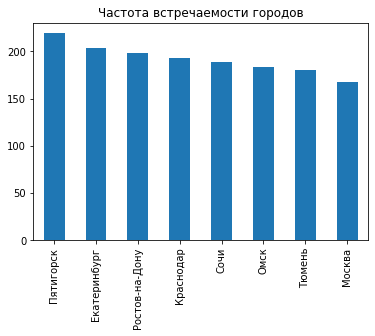

In [12]:
#Строю столбчатую диаграмму для визуализации частоты встречаемости городов
users_data['city'].value_counts().plot.bar()
plt.title('Частота встречаемости городов')
plt.show()

**Вывод:** Частота встречаемости городов не сильно различается. Однако можно выделить то, что наиболее встречаемым городом является Пятигорск, а наименее встречаемый город - Москва.

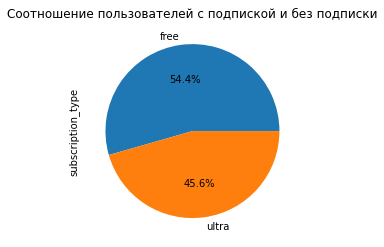

In [13]:
#Строю столбчатую диаграмму для визуализации соотношения пользователей с подпиской и без подписки
users_data['subscription_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Соотношение пользователей с подпиской и без подписки')
plt.show()

**Вывод:** На диаграмме видно, что пользователей без подписки примерно на 8,8 % больше пользователей с подпиской ultra.

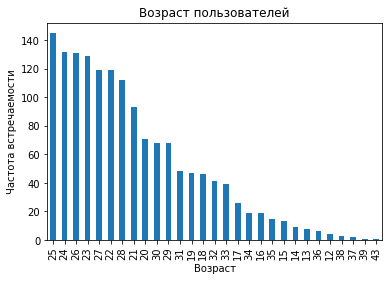

In [14]:
#Строю столбчатую диаграмму для визуализации возраста пользователей
users_data['age'].value_counts().plot.bar()
plt.title('Возраст пользователей')
plt.xlabel('Возраст')
plt.ylabel('Частота встречаемости')
plt.show()

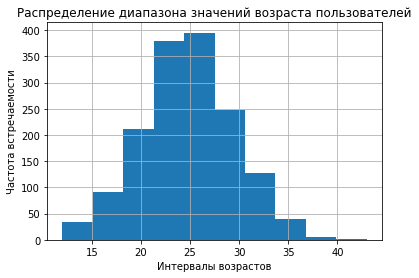

In [15]:
#Строю гистограмму для визуализации распределения диапазона значений возраста пользователей
users_data['age'].hist()
plt.title('Распределение диапазона значений возраста пользователей')
plt.xlabel('Интервалы возрастов')
plt.ylabel('Частота встречаемости')
plt.show()

**Вывод:** Видно, что возраст большинства пользователей сервиса относится к промежутку от 21 до 28. Также можно отметить, что сервис не так популярен среди людей с возрастом до 20 или после 29. Наиболее частые пользователи имеют возраст 25 лет, а меньше всего сервисом пользуются люди, которым больше 35 лет. Более наглядно это распределение диапазона значений возраста пользователей можно увидеть на гистограмме.

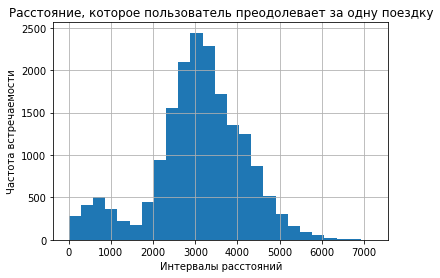

In [16]:
#Строю гистограмму для визуализации расстояния,которое пользователь преодолевает за одну поездку
rides_data['distance'].hist(bins=25)
plt.title('Расстояние, которое пользователь преодолевает за одну поездку')
plt.xlabel('Интервалы расстояний')
plt.ylabel('Частота встречаемости')
plt.show()

In [17]:
#Cмотрю на основные статистические характеристики столбца "distance"
rides_data['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

**Вывод:** Расстояние, которое пользователь преодолевает за одну поездку, находится в диапазоне от 0 до 7212 м. Наиболее часто пользователь проезжает расстояние от 2600 м до 3500 м, наиболее редко встречаются значения выше 5200 м. Среднее расстояние, которое проезжает пользователь, равно 3070 м со стандартным отклонением в 1116 м. Также стоит отметить, что медиана равна 3133 м, что близко к среднему значению.

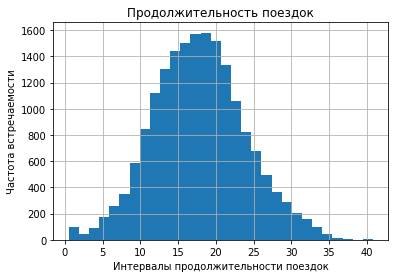

In [18]:
#Строю гистограмму для визуализации продолжительности поездки
rides_data['duration'].hist(bins=30)
plt.title('Продолжительность поездок')
plt.xlabel('Интервалы продолжительности поездок')
plt.ylabel('Частота встречаемости')
plt.show()

In [19]:
#Применяю фильтр для того, чтобы посмотреть на содержимое аномального пика
print(rides_data[rides_data['duration'] < 1])

       user_id     distance  duration       date  month_number
6531       701  4196.445201       0.5 2021-08-31             8
6570       704  4830.824371       0.5 2021-10-14            10
6680       712  4684.004397       0.5 2021-03-04             3
6695       713  5215.642710       0.5 2021-02-25             2
6768       718  5197.436649       0.5 2021-02-11             2
...        ...          ...       ...        ...           ...
17004     1460  5531.335845       0.5 2021-01-19             1
17242     1477  6724.932981       0.5 2021-01-12             1
17314     1483  4445.481070       0.5 2021-03-06             3
17505     1496  5722.551787       0.5 2021-02-14             2
17909     1524  4103.998874       0.5 2021-06-18             6

[95 rows x 5 columns]


In [20]:
#Удаляю аномалии с длительностью менее 1 минуты как технические нереалистичные
rides_data = rides_data[rides_data['duration'] > 1]

**Вывод:** Продолжительность сессии распределена на диапазоне от 0 до 41 мин. Наиболее частая продолжительность сессии - 13-21 мин, редко встречаются продолжительности сессии, находящиеся в диапазонах от 0 до 5 мин и от 33 до 41 мин. Кроме того, стоит отметить аномальный пик около 0. При дальнейшем анализе было выявлено, что в нем содержатся аномальные значения, так как довольно большие расстояния (4000-5000 м) соответствуют малым продолжительностям (0.5 мин). В связи с этим эти значения были удалены из таблицы.

### Объединение данных

In [21]:
#Проверяю количество строк в таблице rides_data до объединения
print(rides_data.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17973 entries, 0 to 18067
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       17973 non-null  int64         
 1   distance      17973 non-null  float64       
 2   duration      17973 non-null  float64       
 3   date          17973 non-null  datetime64[ns]
 4   month_number  17973 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 842.5 KB
None


In [22]:
#Объединяю датафреймы users_data и rides_data в один датафрейм users_and_rides
users_and_rides_df = pd.merge(users_data, rides_data, on='user_id', how='outer' )
#Объединяю предыдущий датафрейм и датафрейм subs_data в финальный датафрейм merged_data
merged_df = pd.merge(users_and_rides_df, subs_data, on='subscription_type', how='outer')
merged_df

,user_id,name,age,city,subscription_type,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
17968,1534,Альберт,25,Краснодар,free,3781.098080,19.822962,2021-11-04,11,8,50,0
17969,1534,Альберт,25,Краснодар,free,2840.423057,21.409799,2021-11-16,11,8,50,0
17970,1534,Альберт,25,Краснодар,free,3826.185507,18.435051,2021-11-18,11,8,50,0
17971,1534,Альберт,25,Краснодар,free,2902.308661,16.674362,2021-11-27,11,8,50,0


In [23]:
#Создаю датафрейм с данными о пользователях без подписки
users_wo_subs_df = merged_df.loc[merged_df['subscription_type'] == 'free']
users_wo_subs_df

,user_id,name,age,city,subscription_type,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
17968,1534,Альберт,25,Краснодар,free,3781.098080,19.822962,2021-11-04,11,8,50,0
17969,1534,Альберт,25,Краснодар,free,2840.423057,21.409799,2021-11-16,11,8,50,0
17970,1534,Альберт,25,Краснодар,free,3826.185507,18.435051,2021-11-18,11,8,50,0
17971,1534,Альберт,25,Краснодар,free,2902.308661,16.674362,2021-11-27,11,8,50,0


In [24]:
#Создаю датафрейм с данными о пользователях с подпиской
users_w_subs_df = merged_df.loc[merged_df['subscription_type'] == 'ultra']
users_w_subs_df

,user_id,name,age,city,subscription_type,distance,duration,date,month_number,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
6495,699,Оксана,22,Москва,ultra,3973.046497,24.671163,2021-08-29,8,6,0,199
6496,699,Оксана,22,Москва,ultra,3288.702563,15.892886,2021-09-12,9,6,0,199
6497,699,Оксана,22,Москва,ultra,3076.159348,14.389525,2021-09-26,9,6,0,199
6498,699,Оксана,22,Москва,ultra,4707.845501,15.839579,2021-10-17,10,6,0,199


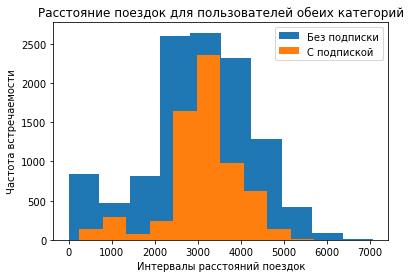

In [25]:
#Строю гистограммы для визуализации информации о расстоянии поездок для пользователей обеих категорий
plt.hist(users_wo_subs_df['distance'], label = 'Без подписки')
plt.hist(users_w_subs_df['distance'], label = 'С подпиской')
plt.title('Расстояние поездок для пользователей обеих категорий')
plt.xlabel('Интервалы расстояний поездок')
plt.ylabel('Частота встречаемости')
plt.legend()
plt.show()

**Вывод:** Гистограммы для визуализации информации о расстоянии поездок имеют похожее распределение, однако стоит отметить, что данных о пользователях без подписки больше. Для пользователей без подписки самое часто встречающее расстояние поездок находится в диапазоне от примерно 2200 до 4000 м, а самое редкое - в диапазоне от 5800 до 7100 м. В то же время для пользователей с подпиской самое часто встречающее расстояние поездок находится в диапазоне от примерно 2500 до 3500 м, а самое редкое - в диапазоне свыше 5000 м. 

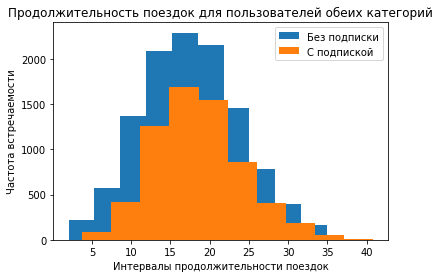

In [26]:
# Строю гистограммы для визуализации информации о времени поездок для пользователей обеих категорий
plt.hist(users_wo_subs_df['duration'], label = 'Без подписки')
plt.hist(users_w_subs_df['duration'], label = 'С подпиской')
plt.title('Продолжительность поездок для пользователей обеих категорий')
plt.xlabel('Интервалы продолжительности поездок')
plt.ylabel('Частота встречаемости')
plt.legend()
plt.show()

**Вывод:** Гистограммы для визуализации информации о времени поездок имеют похожее распределение. Однако стоит отметить, что данных о пользователях без подписки больше. Интересно, что наиболее часто пользователи обеих категорий имеют время поездки из диапазона от 15 до 20 мин. До отметки 15 мин, видно, что частота времени поезки совпадает у пользователей обеих категорий, после отметки 20 мин можно отметить некоторое смещение в сторону большего времени у пользователей с подпиской.

## Подсчет выручки

In [27]:
#Создаю столбец с суммарным расстоянием 
total_df = merged_df.groupby(['user_id','month_number'])['distance'].sum()
#Преобразуем предыдущий столбец в датафрейм
total_df = total_df.to_frame() 
#Переименовываю столбец на total_distance
total_df = total_df.rename(columns={'distance':'total_distance'})
#Округляю значения длительности каждой поездки в исходной объединенной таблице
merged_df['duration'] = np.ceil(merged_df['duration'])
#Добавляю столбик с суммарным кол-вом поездок в предыдущий датафрейм
total_df['rides_amount'] = merged_df.groupby(['user_id','month_number'])['distance'].count()
#Добавляю столбик с суммарным временем поездок в предыдущий датафрейм
total_df['total_duration'] = merged_df.groupby(['user_id','month_number'])['duration'].sum()
total_df

total_distance  rides_amount  total_duration
user_id month_number                                              
1       1                7027.511294             2            42.0
        4                 754.159807             1             7.0
        8                6723.470560             2            46.0
        10               5809.911100             2            32.0
        11               7003.499363             3            56.0
...                              ...           ...             ...
1534    6                3409.468534             2            26.0
        8                7622.453034             2            48.0
        9                4928.173852             1            23.0
        11              13350.015305             4            78.0
        12               2371.711192             1            16.0

[11300 rows x 3 columns]

In [28]:
#Объединяю датафреймы total_df и merged_df в merged по столбцам user_id и month_number
merged = total_df.merge(merged_df[['user_id','month_number', 'start_ride_price', 'minute_price', 'subscription_fee', 'subscription_type']], 
                        on=['user_id', 'month_number'], 
                        how='left')
#Считаю помесячную выручку и сохраняю результаты в столбце revenue
merged['revenue'] = merged['start_ride_price'] * merged['rides_amount'] + merged['minute_price'] * merged['total_duration'] + merged['subscription_fee']
#Добавляю столбец с помесячной выручкой в датафрейм total_df
total_df = total_df.merge(merged[['user_id', 'revenue','month_number', 'subscription_type']], on=['user_id', 'month_number'], how='left')
# Удаление дубликатов
total_df = total_df.drop_duplicates(subset=['user_id', 'month_number'])
total_df.head()

,user_id,month_number,total_distance,rides_amount,total_duration,revenue,subscription_type
0,1,1,7027.511294,2,42.0,451.0,ultra
2,1,4,754.159807,1,7.0,241.0,ultra
3,1,8,6723.470560,2,46.0,475.0,ultra
5,1,10,5809.911100,2,32.0,391.0,ultra
7,1,11,7003.499363,3,56.0,535.0,ultra


## Проверка гипотез

### Проверка гипотезы о том, что пользователи с подпиской тратят больше времени на поездки 

Нулевая гипотеза: Пользователи с подпиской тратят столько же времени на поездки, что и пользователи без подписки \
Альтернативная: Пользователи с подпиской тратят больше времени на поездки

In [29]:
users_w_subs_dur = users_w_subs_df['duration']
users_wo_subs_dur = users_wo_subs_df['duration']

alpha = 0.05

results = st.ttest_ind(users_w_subs_dur, users_wo_subs_dur, alternative='greater')
print('p-значение', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-значение 4.704468074453899e-28
Отвергаем нулевую гипотезу


**Вывод:** Пользователи с подпиской тратят больше времени на поездки.


### Проверка гипотезы о том, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров 

Нулевая гипотеза: Cреднее расстояние, которое проезжают пользователи с подпиской за одну поездку, равно 3130 метров \
Альтернативная:  Cреднее расстояние, которое проезжают пользователи с подпиской за одну поездку, больше 3130 метров

In [30]:
sample = users_w_subs_df['distance']
print('Среднее выборки', sample.mean())
value = 3130

alpha = 0.05

results = st.ttest_1samp(sample, value, alternative='greater')
print('p-значение', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

Среднее выборки 3115.4453880370247
p-значение 0.9195368847849785
Не отвергаем нулевую гипотезу


**Вывод:** Cреднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров.

### Проверка гипотезы о том, что помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

Нулевая гипотеза: Помесячная выручка от пользователей с подпиской по месяцам равна выручке от пользователей без подписки \
Альтернативная: Помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки 

In [31]:
users_w_subs_rev = total_df.loc[total_df['subscription_type'] == 'ultra', 'revenue']
users_wo_subs_rev = total_df.loc[total_df['subscription_type'] == 'free', 'revenue']

alpha = 0.05

results = st.ttest_ind(users_w_subs_rev, users_wo_subs_rev, alternative='greater')
print('p-значение', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-значение 2.0314113674863288e-30
Отвергаем нулевую гипотезу


**Вывод:** Помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

Также для проверки эффективности обновления сервера технической команды можно сравнить данные о количестве обращений до обновления и после него, так как выборки являются зависимыми, то для проверки этой гипотезы нужно использовать двухвыборочный t-тест для зависимых выборок.

## Распределения

6.1 Компания GoFast проводит акцию: пользователям рассылают промокоды на бесплатный месяц подписки. По историческим данным, 10% получивших промокод продлевают подписку после окончания бесплатного периода. Цель акции — получить не менее 100 продлений.
Задача: определить минимальное количество промокодов для рассылки, при котором вероятность получить менее 100 продлений не превышает 5%.

Минимальное количество промокодов: 850


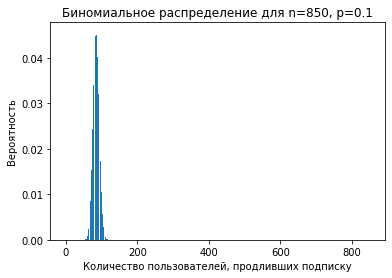

In [32]:
p = 0.1  # вероятность успеха 
k = 100  # количество успехов
alpha = 0.05  # вероятность ошибки 

# Инициализация переменной для минимального количества промокодов
n = 100  

# Ищу минимальное количество промокодов, чтобы P(X >= 100) >= 0.95
while stats.binom.cdf(k - 1, n, p) > 1 - alpha:
    n += 1

# Вывожу минимальное количество промокодов
print(f"Минимальное количество промокодов: {n}")

# Теперь вычисляю биномиальное распределение для найденного n
distr = []

for k_value in range(0, n + 1):
    prob = stats.binom.pmf(k_value, n, p)
    distr.append(prob)

# Строю график распределения
plt.bar(range(0, n + 1), distr)
plt.xlabel('Количество пользователей, продливших подписку')
plt.ylabel('Вероятность')
plt.title(f'Биномиальное распределение для n={n}, p={p}')
plt.show()

6.2 GoFast рассылает push-уведомления в мобильном приложении. Исторически уведомления открывают 40% получателей. Планируется разослать 1 млн уведомлений.
Задача: Используя нормальную аппроксимацию биномиального распределения, построить график и оценить вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

In [33]:
p = 0.4  # вероятность успеха 
n = 1000000  # количество успехов

#апроксимируем биномиальное распределение нормальным
mu = n * p
sigma = sqrt(n * p * (1 - p))

#задаем нормальное распределение
distr = st.norm(mu, sigma)

print('Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей равна', distr.cdf(399500))

Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей равна 0.15371708296369768


**Итоговый вывод**: Был проведен детальный анализ данных сервиса аренды самокатов GoFast. Была сделана предобработка данных, в ходе чего были удалены дубликаты, пропуски в данных, а также изменен тип данных при необходимости. Наибольшей популярностью сервис пользуется в Пятигорске, наименьшей - в Москве. Также, оказалось, что пользователей без подписки примерно на 8,8 % больше пользователей с подпиской ultra. Среди разных возрастных категорий чаще сервис использовали пользователи с возрастом в интервале от 21 до 28, меньше всего - пользователи, которым больше 35 лет. Наиболее часто пользователь проезжает расстояние от 2600 м до 3500 м. При дальнейшем сравнении этих параметров для пользователей с подпиской и без, было выявлено, что в среднем пользователи с подпиской проезжают больше расстояние и тратят больше времени на поездку по сравнению с пользователями без подписки. Более того, помесячная выручка от пользователей с подпиской по месяцам оказалась также выше, чем выручка от пользователей без подписки. Таким образом, для роста бизнеса сервису стоит акцентировать внимание на пользователей с подпиской.